In [7]:
import pdfplumber
import re
import json

def clean_text(text):
    if not text:
        return ""

    text = re.sub(r'(.)\1{2,}', r'\1', text)  
    text = re.sub(r'\s+', ' ', text)          
    return text.strip()

def extract_text_and_tables(pdf_path):
    text_data = []
    table_data = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):

            raw_text = page.extract_text()
            if raw_text:
                paragraphs = re.split(r'\n\s*\n', raw_text)

                for para in paragraphs:
                    para = clean_text(para)

                    if len(para) < 100:
                        continue
                    if para.count('.') < 1:
                        continue

                    text_data.append({
                        "page": page_num + 1,
                        "text": para
                    })

            tables = page.extract_tables({
                "vertical_strategy": "lines",
                "horizontal_strategy": "lines"
            })

            for table in tables:
                if not table:
                    continue

                cleaned_table = []
                for row in table:
                    if any(cell is not None and str(cell).strip() != "" for cell in row):
                        cleaned_table.append([
                            str(cell).strip() if cell else "" for cell in row
                        ])

                if len(cleaned_table) < 2:
                    continue

                table_data.append({
                    "page": page_num + 1,
                    "table": cleaned_table
                })

    return text_data, table_data


def is_high_value_financial_table(table):
    text = " ".join([" ".join(row) for row in table]).lower()

    strong_headers = [
        "npa", "gross npa", "net npa",
        "provision", "write off",
        "advances", "liabilities",
        "assets", "borrowings",
        "exposure"
    ]

    reject_keywords = [
        "strategy", "strategic", "customer",
        "esg", "sustainability", "value creation",
        "stakeholder", "digital", "governance",
        "subsidiary", "market positioning",
        "progress", "target", "penetration"
    ]

    if any(k in text for k in reject_keywords):
        return False

    if not any(k in text for k in strong_headers):
        return False

    numbers = re.findall(r'\d+\.?\d*', text)
    if len(numbers) < 15:
        return False

    percent_count = text.count('%')
    if percent_count > 0 and len(numbers) < 10:
        return False

    if len(table) < 3:
        return False

    if max(len(row) for row in table) < 2:
        return False

    return True


def filter_financial_tables(table_data):
    filtered = []

    for item in table_data:
        if is_high_value_financial_table(item["table"]):
            filtered.append(item)

    return filtered


def save_json(data, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


if __name__ == "__main__":
    pdf_path = "annual_report_for_the_year_2023_2024.pdf"  # 🔁 change this

    text_data, table_data = extract_text_and_tables(pdf_path)

    print(f"\n Text paragraphs extracted: {len(text_data)}")
    print(f" Tables extracted: {len(table_data)}")

    
    financial_tables = filter_financial_tables(table_data)

    print(f"\n High-value financial tables: {len(financial_tables)}\n")

    
    for i, item in enumerate(financial_tables[:5]):
        print(f"\n--- Page {item['page']} ---")
        for row in item["table"][:5]:
            print(row)

    # 🔹 Save
    save_json(financial_tables, "financial_tables.json")

    print("\n Saved as financial_tables.json")


 Text paragraphs extracted: 446
 Tables extracted: 286

 High-value financial tables: 11


--- Page 330 ---
['Deposits1', 'Advances1,2', 'Investments1,4', 'Borrowings1', 'Foreign\nCurrency\nAssets3', 'Foreign\nCurrency\nLiabilities3']
['20,523.02', '9,394.96', '111,706.75', '-', '13,512.02', '565.97']
['41,749.42', '16,884.89', '25,962.79', '66.69', '7,254.66', '1,272.63']
['19,843.30', '15,640.85', '8,165.44', '716.26', '3,135.31', '925.25']
['34,001.38', '29,615.90', '7,911.23', '3,100.29', '8,408.57', '4,048.04']

--- Page 338 ---
['31 March, 2024', '', '', '']
['Advances', 'Investments', 'Others1', 'Total']
['17,019.09', '1,585.14', '-', '18,604.23']
['-', '-', '-', '-']
['14,404.64', '25.92', '-', '14,430.56']

--- Page 339 ---
['31 March, 2024', '', '', '']
['Advances', 'Investments', 'Others1', 'Total']
['13,579.98', '1,465.33', '-', '15,045.31']
['-', '-', '-', '-']
['6,320.51', '50.54', '-', '6,371.05']

--- Page 339 ---
['31 March, 2024', '', '', '']
['Advances', 'Investment

In [8]:
def clean_field_name(name):
    name = re.sub(r'\d+', '', name)

    name = re.sub(r'[^a-zA-Z\s]', '', name)

    name = re.sub(r'\s+', ' ', name)

    return name.strip()


def clean_value(value):
    value = value.replace(',', '')
    return value.strip()

In [9]:
def table_to_structured_text(table):
    headers = table[0]
    rows = table[1:]

    structured_data = []

    for row in rows:
        row_text = []

        for h, v in zip(headers, row):
            if v and v != "-":
                clean_h = clean_field_name(h)
                clean_v = clean_value(v)

                if clean_h:
                    row_text.append(f"{clean_h}: {clean_v}")

        if row_text:
            structured_data.append(", ".join(row_text))

    return structured_data

In [10]:
def convert_all_tables(financial_tables):
    converted = []

    for item in financial_tables:
        page = item["page"]
        table = item["table"]

        structured_rows = table_to_structured_text(table)

        for row in structured_rows:
            converted.append({
                "page": page,
                "text": row
            })

    return converted

In [11]:
structured_data = convert_all_tables(financial_tables)

print(f"\n Structured rows: {len(structured_data)}\n")

for i in structured_data[:10]:
    print(f"Page {i['page']}: {i['text']}")


 Structured rows: 101

Page 330: Deposits: 20523.02, Advances: 9394.96, Investments: 111706.75, Foreign Currency Assets: 13512.02, Foreign Currency Liabilities: 565.97
Page 330: Deposits: 41749.42, Advances: 16884.89, Investments: 25962.79, Borrowings: 66.69, Foreign Currency Assets: 7254.66, Foreign Currency Liabilities: 1272.63
Page 330: Deposits: 19843.30, Advances: 15640.85, Investments: 8165.44, Borrowings: 716.26, Foreign Currency Assets: 3135.31, Foreign Currency Liabilities: 925.25
Page 330: Deposits: 34001.38, Advances: 29615.90, Investments: 7911.23, Borrowings: 3100.29, Foreign Currency Assets: 8408.57, Foreign Currency Liabilities: 4048.04
Page 330: Deposits: 48295.64, Advances: 42527.96, Investments: 10105.92, Borrowings: 7239.27, Foreign Currency Assets: 5660.88, Foreign Currency Liabilities: 8118.47
Page 330: Deposits: 47234.34, Advances: 17823.76, Investments: 6861.73, Borrowings: 6117.10, Foreign Currency Assets: 4895.40, Foreign Currency Liabilities: 7226.87
Page 330

In [12]:

import pandas as pd
import numpy as np
import re

rows = []

for item in structured_data:
    txt = item["text"]

    dep = re.search(r"Deposits:\s*([\d\.]+)", txt)
    adv = re.search(r"Advances:\s*([\d\.]+)", txt)
    inv = re.search(r"Investments:\s*([\d\.]+)", txt)

    deposits = float(dep.group(1)) if dep else np.nan
    advances = float(adv.group(1)) if adv else np.nan
    investments = float(inv.group(1)) if inv else np.nan

    rows.append({
        "page": item["page"],
        "deposits": deposits,
        "advances": advances,
        "investments": investments
    })

df = pd.DataFrame(rows)

df = df.dropna(subset=["deposits", "advances", "investments"], how="all")


df["LDR"] = np.where(df["deposits"] > 0, df["advances"] / df["deposits"], np.nan)
df["INV_RATIO"] = np.where(df["deposits"] > 0, df["investments"] / df["deposits"], np.nan)


def risk_level(ldr):
    if pd.isna(ldr):
        return "Unknown"
    elif ldr > 0.90:
        return "High"
    elif ldr > 0.70:
        return "Moderate"
    else:
        return "Low"

df["risk_level"] = df["LDR"].apply(risk_level)


def comments(row):
    notes = []

    if row["LDR"] > 1:
        notes.append("Advances exceed deposits")
    elif row["LDR"] > 0.85:
        notes.append("Aggressive lending")
    elif row["LDR"] < 0.60:
        notes.append("Conservative lending")

    if row["INV_RATIO"] > 2:
        notes.append("Very high investment concentration")
    elif row["INV_RATIO"] > 1:
        notes.append("High investments")

    if row["deposits"] < 10000:
        notes.append("Low deposit base")

    return "; ".join(notes)

df["observations"] = df.apply(comments, axis=1)


total_dep = df["deposits"].sum()
total_adv = df["advances"].sum()
total_inv = df["investments"].sum()

overall_ldr = total_adv / total_dep
overall_inv = total_inv / total_dep

print("====================================")
print("BANK AUDIT SUMMARY")
print("====================================")
print(f"Total Deposits     : {total_dep:,.2f}")
print(f"Total Advances     : {total_adv:,.2f}")
print(f"Total Investments  : {total_inv:,.2f}")
print(f"Overall LDR        : {overall_ldr:.2%}")
print(f"Investment Ratio   : {overall_inv:.2%}")

if overall_ldr > 0.90:
    print("Overall Risk       : HIGH")
elif overall_ldr > 0.70:
    print("Overall Risk       : MODERATE")
else:
    print("Overall Risk       : LOW")

print("====================================")


print(df.head(20))

df.to_excel("bank_audit_analysis2.xlsx", index=False)

print("Saved file: bank_audit_analysis.xlsx")

BANK AUDIT SUMMARY
Total Deposits     : 2,137,282.78
Total Advances     : 1,930,136.76
Total Investments  : 662,684.44
Overall LDR        : 90.31%
Investment Ratio   : 31.01%
Overall Risk       : HIGH
    page    deposits   advances  investments        LDR  INV_RATIO risk_level  \
0    330    20523.02    9394.96    111706.75   0.457777   5.442998        Low   
1    330    41749.42   16884.89     25962.79   0.404434   0.621872        Low   
2    330    19843.30   15640.85      8165.44   0.788218   0.411496   Moderate   
3    330    34001.38   29615.90      7911.23   0.871021   0.232674   Moderate   
4    330    48295.64   42527.96     10105.92   0.880576   0.209251   Moderate   
5    330    47234.34   17823.76      6861.73   0.377347   0.145270        Low   
6    330    84434.44   33642.06     12412.06   0.398440   0.147002        Low   
7    330   152613.69   67809.25     22069.38   0.444320   0.144609        Low   
8    330    42875.57  200276.23     24444.06   4.671104   0.570116    

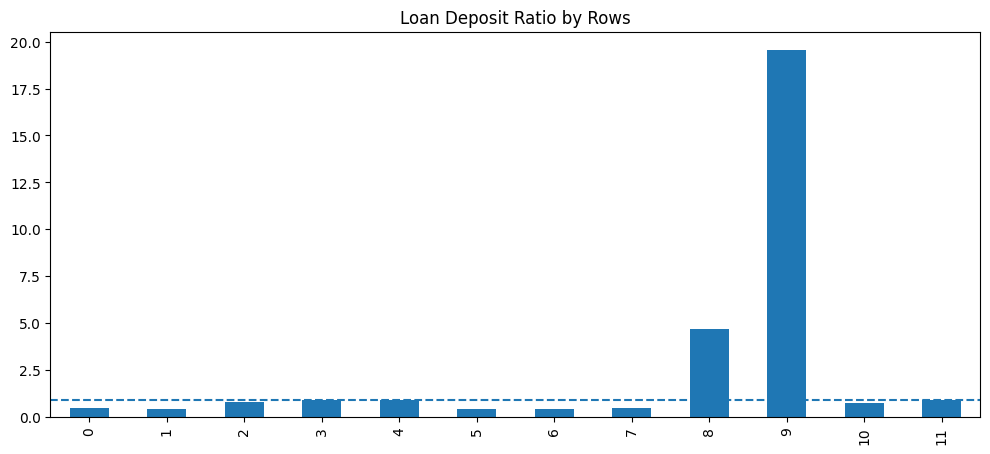

In [13]:
import matplotlib.pyplot as plt

df["LDR"].plot(kind="bar", figsize=(12,5))
plt.axhline(0.9, linestyle="--")
plt.title("Loan Deposit Ratio by Rows")
plt.show()

In [14]:
import pandas as pd
import numpy as np


total_deposits = df["deposits"].sum()
total_advances = df["advances"].sum()
total_investments = df["investments"].sum()

overall_ldr = total_advances / total_deposits
overall_inv_ratio = total_investments / total_deposits

high_risk_count = (df["risk_level"] == "High").sum()
moderate_risk_count = (df["risk_level"] == "Moderate").sum()
low_risk_count = (df["risk_level"] == "Low").sum()

total_rows = len(df)


top_risky = df.sort_values(by="LDR", ascending=False).head(10).copy()

top_risky = top_risky[[
    "page",
    "deposits",
    "advances",
    "investments",
    "LDR",
    "risk_level",
    "observations"
]]


summary = pd.DataFrame({
    "Metric": [
        "Total Rows Analyzed",
        "Total Deposits",
        "Total Advances",
        "Total Investments",
        "Overall Loan Deposit Ratio",
        "Overall Investment Ratio",
        "High Risk Rows",
        "Moderate Risk Rows",
        "Low Risk Rows"
    ],
    "Value": [
        total_rows,
        total_deposits,
        total_advances,
        total_investments,
        overall_ldr,
        overall_inv_ratio,
        high_risk_count,
        moderate_risk_count,
        low_risk_count
    ]
})


with pd.ExcelWriter("bank_audit_professional_report.xlsx", engine="openpyxl") as writer:
    
    summary.to_excel(writer, sheet_name="Executive Summary", index=False)
    df.to_excel(writer, sheet_name="Detailed Analysis", index=False)
    top_risky.to_excel(writer, sheet_name="Top 10 Risky Rows", index=False)

print("Saved: bank_audit_professional_report2.xlsx")

Saved: bank_audit_professional_report2.xlsx
